In [111]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

O sistema da ANP exporta os dados por semestre. Antes de qualquer análise, consolide os quatro arquivos de 2024 e 2025
em um único DataFrame. Confirme que a operação foi realizada corretamente verificando o número de linhas e as
primeiras entradas do resultado.


In [112]:
df_2024_1 = pd.read_csv('_2024.01.csv', sep=';', decimal=',')
df_2024_2 = pd.read_csv('_2024.02.csv', sep=';', decimal=',')
df_2025_1 = pd.read_csv('_2025.01.csv', sep=';', decimal=',')
df_2025_2 = pd.read_csv('_2025.02.csv', sep=';', decimal=',')


C:\Users\costa.patrick\AppData\Local\Temp\ipykernel_29544\3382592467.py:3: DtypeWarning: Columns (0: Regiao - Sigla, 1: Estado - Sigla, 2: Municipio, 3: Revenda, 4: CNPJ da Revenda, 5: Nome da Rua, 6: Numero Rua, 7: Complemento, 8: Bairro, 9: Cep, 10: Produto, 11: Data da Coleta, 12: Unidade de Medida, 13: Bandeira) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025_1 = pd.read_csv('_2025.01.csv', sep=';', decimal=',')


In [113]:
df = pd.concat([df_2024_1, df_2024_2, df_2025_1, df_2025_2],
ignore_index=True)
print(df.shape) 
display(df.head())


(1712267, 16)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


O diretor quer entender como se comportaram os preços médios da Gasolina C no estado do Rio de Janeiro entre 2024 e
2025. Calcule a média do Valor de Venda por município e apresente os resultados do maior para o menor. Quais municípios
praticaram os maiores preços médios no período?

In [114]:
df_rj = df.loc[(df['Estado - Sigla'] == 'RJ') &  (df['Produto'] == 'GASOLINA')]
df_rj

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
122,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO DE COMBUSTIVEIS CONTORNO DE CAMPOS LTDA,31.212.889/0002-85,AVENIDA NILO PECANHA,614,/822 PATIO,PQ SANTO AMARO,28030-035,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,VIBRA
130,SE,RJ,CAMPOS DOS GOYTACAZES,ARARA FLUMINENSE COMERCIO DE COMBUSTIVEIS LTDA.,07.614.346/0004-71,AVENIDA ALBERTO TORRES,100,NaN,CENTRO,28010-117,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,RAIZEN
131,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO SAO LUCAS DE CAMPOS LTDA,04.718.173/0001-09,"RODOVIA BR-101 KM 80,5",S/N,NaN,IBITIOCA,28120-000,GASOLINA,01/01/2024,5.89,NaN,R$ / litro,RAIZEN
133,SE,RJ,CAMPOS DOS GOYTACAZES,MOTO MERCANTIL CAMPISTA S A,28.935.153/0001-40,RUA DOS GOYTACAZES,342,NaN,CENTRO,28010-460,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,VIBRA
136,SE,RJ,CAMPOS DOS GOYTACAZES,G.S. NOGUEIRA COMBUSTÍVEIS LTDA,03.784.646/0001-03,RUA JOAQUIM LORENA,6,NaN,URURAÍ,28020-230,GASOLINA,01/01/2024,5.79,NaN,R$ / litro,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1622777,SE,RJ,NOVA FRIBURGO,F.MURY DESIGN PROPAGANDA E PUBLICIDADE LTDA,7707130000299,ESTRADA FRIBURGO AMPARO,15604,LP N 0130/2018 LP N 0440/2019,CHACARA PARAISO,28605-520,GASOLINA,30/12/2025,6.69,NaN,R$ / litro,VIBRA
1622806,SE,RJ,MARICA,POSTO NOVO RECREIO LTDA,24787241000352,AVENIDA MAYSA,12656,LOTE 4 A QUADRA 24,BARRA DE MARICÁ,24915-400,GASOLINA,30/12/2025,6.39,NaN,R$ / litro,BRANCA
1622972,SE,RJ,ANGRA DOS REIS,AUTO POSTO ENCRUZO DA ENSEADA LTDA,3340868000129,RUA PREFEITO JOAO GREGORIO GALINDO,S/N,LOTE 02,CAMPO BELO (CUNHAMBEBE),23932-400,GASOLINA,31/12/2025,6.69,NaN,R$ / litro,IPIRANGA
1622973,SE,RJ,TRES RIOS,AUTO LUBRIFICADORA TRIRRIENSE LTDA,28863579000135,RUA BARAO DE ENTRE RIOS,401,NaN,CENTRO,25802-315,GASOLINA,31/12/2025,6.89,NaN,R$ / litro,IPIRANGA


In [115]:
df_med_rj = df_rj.groupby('Municipio')['Valor de Venda'].mean().reset_index()
df_med_rj = df_med_rj.sort_values(by= 'Valor de Venda', ascending=False)
df_rj_top10 = df_med_rj.head(5)

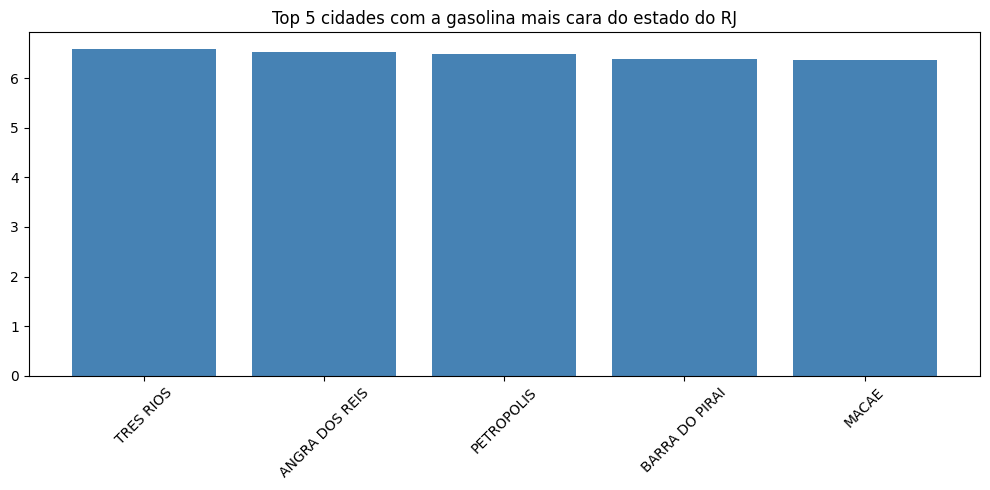

In [116]:

plt.figure(figsize=(10, 5))
plt.bar(df_rj_top10 ['Municipio'], df_rj_top10['Valor de Venda'], color='steelblue')
plt.title('Top 5 cidades com a gasolina mais cara do estado do RJ')
plt.xticks(rotation=45)  
plt.tight_layout()    
plt.show()

Ainda com foco na Gasolina C no Rio de Janeiro, identifique os postos com preços estatisticamente atípicos. Calcule o IQR e
os limites para o Valor de Venda. Existem postos praticando preços fora do padrão? Apresente os grupos de outliers
superiores e inferiores ordenados de forma adequada. Se o limite inferior for negativo, o que isso indica?


In [117]:
df_posto = df_rj.groupby('Revenda')['Valor de Venda'].mean().reset_index()
df_posto = df_posto.sort_values(by= 'Valor de Venda', ascending=False)
df_posto_10 = df_posto.head(5)

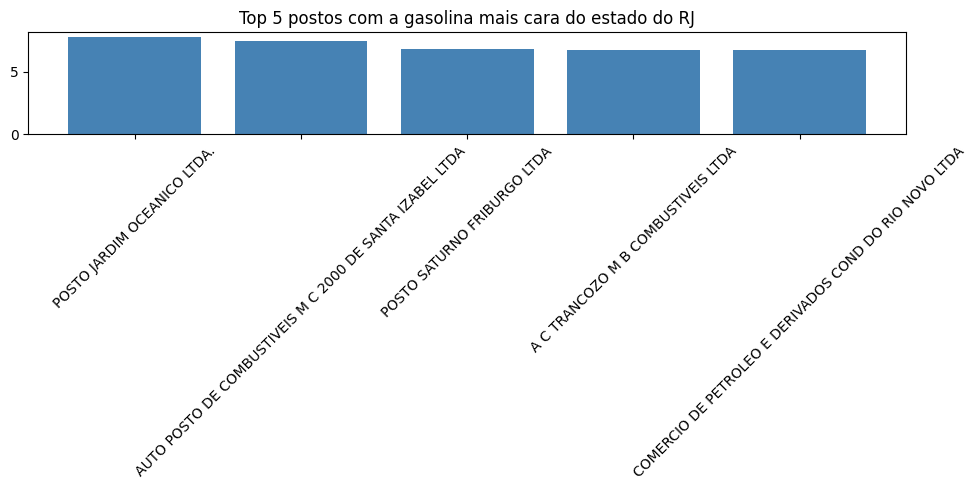

In [118]:
plt.figure(figsize=(10, 5))
plt.bar(df_posto_10 ['Revenda'], df_posto_10['Valor de Venda'], color='steelblue')
plt.title('Top 5 postos com a gasolina mais cara do estado do RJ')
plt.xticks(rotation=45)  
plt.tight_layout()    
plt.show()

In [119]:
array_posto = np.array(df_posto['Valor de Venda'])
print(array_posto)

[7.75067416 7.415      6.82444444 6.74215686 6.71352941 6.71295082
 6.70469136 6.69666667 6.69576923 6.69       6.69       6.68906667
 6.67028169 6.67       6.665      6.66227273 6.656      6.61461538
 6.60436893 6.59756757 6.576      6.57444444 6.56375    6.56142857
 6.55833333 6.55712329 6.54869565 6.54581395 6.54531915 6.54
 6.54       6.54       6.53769231 6.53672131 6.53590164 6.53084507
 6.53038462 6.52978495 6.52878788 6.52818182 6.5257971  6.52333333
 6.52125    6.51857143 6.5145283  6.51307692 6.50411765 6.49882353
 6.49       6.49       6.49       6.49       6.49       6.49
 6.49       6.49       6.49       6.48046512 6.48       6.4797561
 6.47571429 6.47095238 6.466      6.46333333 6.46105263 6.45722222
 6.45470588 6.45410256 6.45216216 6.45027778 6.44931034 6.44584615
 6.44325581 6.443125   6.44081967 6.44       6.44       6.43989362
 6.43731183 6.43722222 6.43631579 6.43534884 6.43492063 6.43487179
 6.43470588 6.43305556 6.432      6.43065934 6.42780822 6.42763441
 6.42375

In [120]:
minimo = np.min (array_posto)
maximo = np.max (array_posto)
amplitude = maximo - minimo 
q1 = np.percentile(array_posto, 25)
q3 = np.percentile(array_posto, 75)

iqr = q3 - q1
limite_superior = q3 + (1.5*iqr)
limite_inferior = q1 - (1.5*iqr)

print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')

Limite Superior 6.936768796992482
Limite Inferior 4.945385338345865


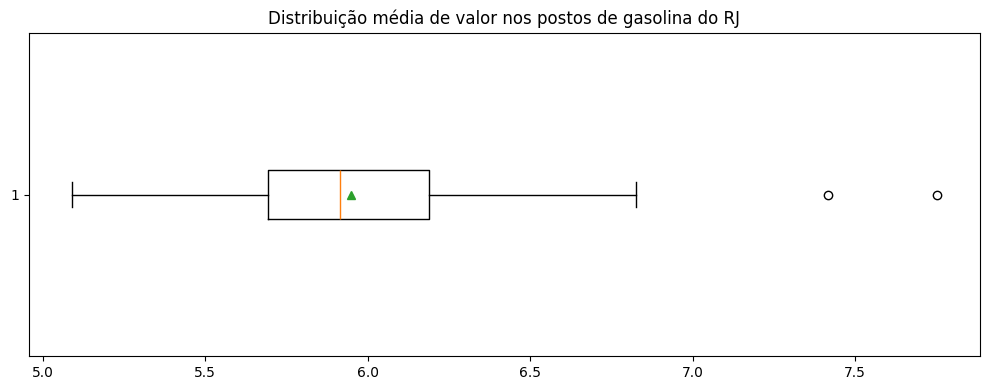

In [121]:
plt.figure(figsize=(10, 4))    
# horizontal: largura maior que altura
plt.boxplot(array_posto, vert=False, showmeans=True)
plt.title('Distribuição média de valor nos postos de gasolina do RJ')
plt.tight_layout()
plt.show()

In [122]:
df_posto_sup = df_posto.loc[df_posto['Valor de Venda'] > limite_superior]
df_posto_sup

,Revenda,Valor de Venda
690,POSTO JARDIM OCEANICO LTDA.,7.750674
76,AUTO POSTO DE COMBUSTIVEIS M C 2000 DE SANTA I...,7.415000


In [123]:
df_posto_inf = df_posto.loc[df_posto['Valor de Venda'] < limite_inferior]
df_posto_inf

,Revenda,Valor de Venda


O diretor quer comparar o preço médio do Etanol Hidratado entre RJ e SP em 2024 e 2025. Filtre os dados para os dois
estados e calcule a média do Valor de Venda para cada um. Em seguida, aplique o critério de outliers em cada estado
separadamente. Os limites e os casos atípicos são semelhantes ou diferentes entre os dois estados?

In [124]:
df_rj_etanol = df.loc[(df['Estado - Sigla'] == 'RJ') &  (df['Produto'] == 'ETANOL')]
df_rj_etanol

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
125,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO DE COMBUSTIVEIS CONTORNO DE CAMPOS LTDA,31.212.889/0002-85,AVENIDA NILO PECANHA,614,/822 PATIO,PQ SANTO AMARO,28030-035,ETANOL,01/01/2024,4.39,NaN,R$ / litro,VIBRA
128,SE,RJ,CAMPOS DOS GOYTACAZES,ARARA FLUMINENSE COMERCIO DE COMBUSTIVEIS LTDA.,07.614.346/0004-71,AVENIDA ALBERTO TORRES,100,NaN,CENTRO,28010-117,ETANOL,01/01/2024,4.29,NaN,R$ / litro,RAIZEN
135,SE,RJ,CAMPOS DOS GOYTACAZES,MOTO MERCANTIL CAMPISTA S A,28.935.153/0001-40,RUA DOS GOYTACAZES,342,NaN,CENTRO,28010-460,ETANOL,01/01/2024,4.29,NaN,R$ / litro,VIBRA
138,SE,RJ,CAMPOS DOS GOYTACAZES,G.S. NOGUEIRA COMBUSTÍVEIS LTDA,03.784.646/0001-03,RUA JOAQUIM LORENA,6,NaN,URURAÍ,28020-230,ETANOL,01/01/2024,4.09,NaN,R$ / litro,BRANCA
143,SE,RJ,CAMPOS DOS GOYTACAZES,CAMPOS GAROUPA LTDA.,03.581.079/0002-60,AVENIDA 15 DE NOVEMBRO,353,NaN,CENTRO,28030-002,ETANOL,01/01/2024,4.17,NaN,R$ / litro,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521258,SE,RJ,NITEROI,JUTURNAIBA COMERCIO DE COMBUSTIVEIS LTDA.,9087994000108,ESTRADA FRANCISCO DA CRUZ NUNES,9163,NaN,ITAIPU,24340-000,ETANOL,30/12/2025,4.89,NaN,R$ / litro,IPIRANGA
1521260,SE,RJ,NOVA FRIBURGO,F.MURY DESIGN PROPAGANDA E PUBLICIDADE LTDA,7707130000299,ESTRADA FRIBURGO AMPARO,15604,LP N 0130/2018 LP N 0440/2019,CHACARA PARAISO,28605-520,ETANOL,30/12/2025,5.19,NaN,R$ / litro,VIBRA
1521282,SE,RJ,MARICA,POSTO NOVO RECREIO LTDA,24787241000352,AVENIDA MAYSA,12656,LOTE 4 A QUADRA 24,BARRA DE MARICÁ,24915-400,ETANOL,30/12/2025,4.69,NaN,R$ / litro,BRANCA
1521428,SE,RJ,TRES RIOS,AUTO LUBRIFICADORA TRIRRIENSE LTDA,28863579000135,RUA BARAO DE ENTRE RIOS,401,NaN,CENTRO,25802-315,ETANOL,31/12/2025,5.39,NaN,R$ / litro,IPIRANGA


In [125]:
df_sp_etanol = df.loc[(df['Estado - Sigla'] == 'SP') &  (df['Produto'] == 'ETANOL')]
df_sp_etanol

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
285,SE,SP,POA,PORTAL DE POA AUTO POSTO LTDA,04.576.763/0001-36,RODOVIA JOAO AFONSO DE SOUZA CASTELLANO,1890,NaN,VILA JAU,08559-000,ETANOL,01/01/2024,3.12,NaN,R$ / litro,BRANCA
289,SE,SP,POA,AUTO POSTO FLOR DE CALMON LTDA,60.176.211/0001-01,AVENIDA BRASIL,1170,NaN,CALMON VIANA,08560-010,ETANOL,01/01/2024,3.39,NaN,R$ / litro,BRANCA
291,SE,SP,POA,AUTO POSTO ESTÂNCIA HIDROMINERAL DE POÁ LTDA.,03.017.060/0001-05,AVENIDA PREFEITO FRANCISCO RODRIGUES FILHO,300,NaN,CENTRO,08561-200,ETANOL,01/01/2024,3.19,NaN,R$ / litro,BRANCA
295,SE,SP,POA,CENTRO AUTOMOTIVO REAL LESTE LTDA,01.456.575/0001-86,AVENIDA LUCAS NOGUEIRA GARCEZ,677,NaN,V STA MARIA,08563-100,ETANOL,01/01/2024,3.36,NaN,R$ / litro,IPIRANGA
299,SE,SP,SAO JOSE DO RIO PRETO,POSTO ITAMARATI - ANANDA LTDA.,03.473.355/0001-96,"RUA PEDRO AMARAL,",3581,NaN,VILA ERCILIA,15014-000,ETANOL,01/01/2024,3.09,NaN,R$ / litro,VIBRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521773,SE,SP,ARARAQUARA,AUTO POSTO 22 DE AGOSTO ARARAQUARA LTDA,35826432000130,AVENIDA VINTE E DOIS DE AGOSTO,479,NaN,VILA XAVIER,14801-970,ETANOL,31/12/2025,3.97,NaN,R$ / litro,BRANCA
1521783,SE,SP,ARARAQUARA,BIO SEVEN POSTO DE COMBUSTIVEIS E LUBRIFICANTE...,40270089000120,AVENIDA ANTONIO GOMES DA SILVA,65,NaN,JARDIM SAO FRANCISCO,14806-657,ETANOL,31/12/2025,3.97,NaN,R$ / litro,BRANCA
1521786,SE,SP,BIRIGUI,AUTO POSTO MAYTA LTDA,31206891000160,RUA DOUTOR ARTHUR CORDEIRO,620,NaN,PATRIMONIO SILVARES,16201-003,ETANOL,31/12/2025,4.09,NaN,R$ / litro,VIBRA
1521789,SE,SP,VARZEA PAULISTA,MALU SANTOS COMERCIO DE COMBUSTIVEIS LTDA,41256798000114,RUA SOROCABA,605,NaN,JARDIM PAULISTA,13222-005,ETANOL,31/12/2025,4.29,NaN,R$ / litro,BRANCA


In [126]:
array_rj = np.array(df_rj_etanol['Valor de Venda'])
print(array_rj)

[4.39 4.29 4.29 ... 4.69 5.39 5.09]


In [127]:
minimo = np.min (array_rj)
maximo = np.max (array_rj)
amplitude = maximo - minimo 

q1 = np.percentile(array_rj, 25)
q3 = np.percentile(array_rj, 75)
media = np.mean(array_rj)

iqr = q3 - q1
limite_superior = q3 + (1.5*iqr)
limite_inferior = q1 - (1.5*iqr)

print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')
print(f'Média é: {media}')

Limite Superior 5.44
Limite Inferior 3.4400000000000004
Média é: 4.4344866618124055


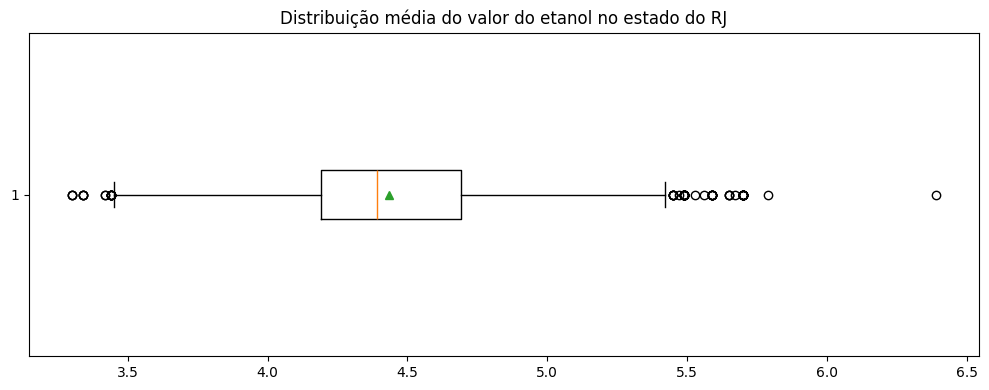

In [128]:
plt.figure(figsize=(10, 4))    
# horizontal: largura maior que altura
plt.boxplot(array_rj, vert=False, showmeans=True)
plt.title('Distribuição média do valor do etanol no estado do RJ')
plt.tight_layout()
plt.show()

In [129]:
array_sp = np.array(df_sp_etanol['Valor de Venda'])
print(array_sp)

[3.12 3.39 3.19 ... 4.09 4.29 4.19]


In [130]:
minimo = np.min (array_sp)
maximo = np.max (array_sp)
amplitude = maximo - minimo 

q1 = np.percentile(array_sp, 25)
q3 = np.percentile(array_sp, 75)
media = np.mean(array_sp)
iqr = q3 - q1
limite_superior = q3 + (1.5*iqr)
limite_inferior = q1 - (1.5*iqr)

print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')
print(f'Média é: {media}')

Limite Superior 4.72
Limite Inferior 3.04
Média é: 3.896278944665868


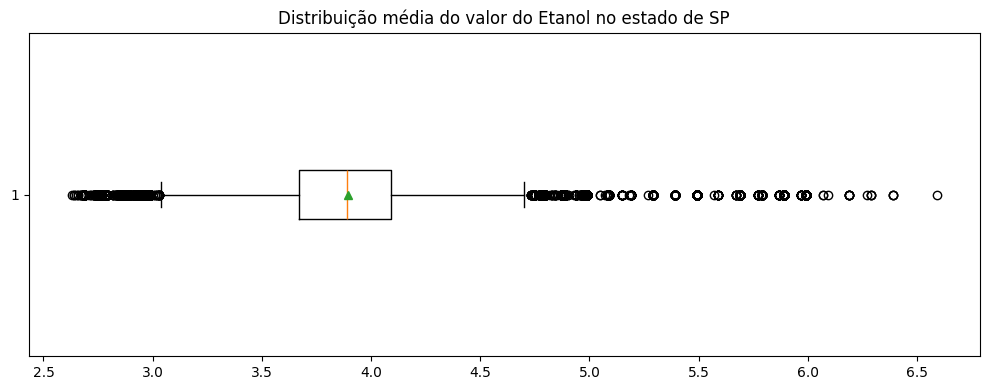

In [131]:
plt.figure(figsize=(10, 4))    
# horizontal: largura maior que altura
plt.boxplot(array_sp, vert=False, showmeans=True)
plt.title('Distribuição média do valor do Etanol no estado de SP')
plt.tight_layout()
plt.show()

A diretoria quer entender como os preços da Gasolina C se distribuem entre os diferentes bairros da cidade do Rio de
Janeiro. Existem bairros com dados atípicos?


In [132]:
df_rio_capital = df.loc[(df['Municipio'] == 'RIO DE JANEIRO') &  (df['Produto'] == 'GASOLINA')]
df_rio_capital

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
2309,SE,RJ,RIO DE JANEIRO,POSTO DE COMBUSTIVEIS CANDIDO BENICIO LTDA,08.833.560/0001-39,RUA CANDIDO BENICIO,2742,NaN,PRACA SECA,22733-001,GASOLINA,02/01/2024,5.29,NaN,R$ / litro,VIBRA
2313,SE,RJ,RIO DE JANEIRO,POSTO E GARAGEM DOM HELDER CAMARA LTDA,04.802.584/0001-70,AVENIDA DOM HELDER CAMARA,4539,NaN,DEL CASTILHO,20771-000,GASOLINA,02/01/2024,5.69,NaN,R$ / litro,RAIZEN
2319,SE,RJ,RIO DE JANEIRO,POSTO DE GASOLINA ALTO ASTRAL DO MEIER LTDA,08.408.393/0001-89,RUA MEDINA,137,NaN,MEIER,20735-130,GASOLINA,02/01/2024,5.19,NaN,R$ / litro,BRANCA
2322,SE,RJ,RIO DE JANEIRO,POSTO DE GASOLINA JAGUAR DO ANIL LTDA,07.752.635/0001-94,AVENIDA TEN. CEL. MUNIZ DE ARAGAO,1240,NaN,ANIL,22765-008,GASOLINA,02/01/2024,5.09,NaN,R$ / litro,BRANCA
2328,SE,RJ,RIO DE JANEIRO,MARQUES'S PETER AUTO POSTO LTDA,05.570.770/0001-93,RUA JOSE DOMINGUES,250,NaN,ENCANTADO,20756-130,GASOLINA,02/01/2024,5.68,NaN,R$ / litro,VIBRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1621057,SE,RJ,RIO DE JANEIRO,POSTO DE ABASTECIMENTO BARRA MONTEIRO LTDA,9329262000179,ESTRADA DO MONTEIRO,1697,NaN,CAMPO GRANDE,23036-340,GASOLINA,29/12/2025,6.09,NaN,R$ / litro,RAIZEN
1621071,SE,RJ,RIO DE JANEIRO,AUTO POSTO GALEGO DO RIO DA PRATA LTDA,9042671000190,ESTRADA DO CABUCU,1765,NaN,CAMPO GRANDE,23017-250,GASOLINA,29/12/2025,5.79,NaN,R$ / litro,BRANCA
1621121,SE,RJ,RIO DE JANEIRO,GNVIA RIO POSTO DE SERVIÇOS LTDA.,6218809000170,RUA CONSELHEIRO GALVAO,926,NaN,ROCHA MIRANDA,21540-000,GASOLINA,29/12/2025,5.74,NaN,R$ / litro,BRANCA
1621176,SE,RJ,RIO DE JANEIRO,AUTO POSTO NOVO BARREIROS DE RAMOS LTDA,9409922000121,RUA BARREIROS,873,NaN,RAMOS,21031-754,GASOLINA,29/12/2025,5.89,NaN,R$ / litro,BRANCA


In [133]:
df_med_rio = df_rio_capital.groupby('Bairro')['Valor de Venda'].mean().reset_index()
df_med_rio = df_med_rio.sort_values(by= 'Valor de Venda', ascending=False)
df_rio_top10 = df_med_rio.head(5)

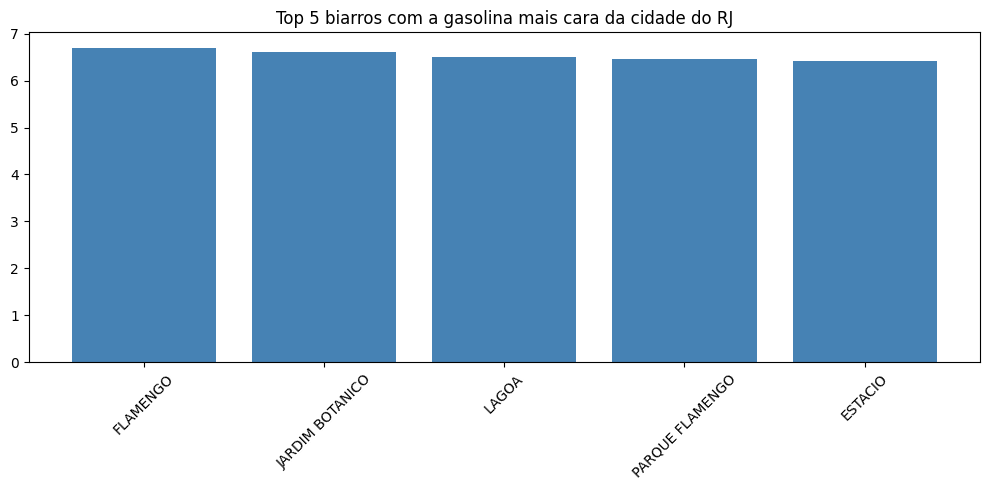

In [134]:
plt.figure(figsize=(10, 5))
plt.bar(df_rio_top10 ['Bairro'], df_rio_top10 ['Valor de Venda'], color='steelblue')
plt.title('Top 5 biarros com a gasolina mais cara da cidade do RJ')
plt.xticks(rotation=45)  
plt.tight_layout()    
plt.show()

In [135]:
array_rio = np.array(df_med_rio['Valor de Venda'])
print(array_rio)

[6.69666667 6.61461538 6.50538462 6.45470588 6.41688172 6.29192308
 6.29       6.29       6.26614035 6.23736111 6.1928169  6.19
 6.19       6.19       6.16284091 6.13559192 6.115      6.11
 6.07920792 6.0655102  6.06172932 6.06058824 6.05423529 6.04681818
 6.04       6.03909091 6.02631068 5.99594059 5.995      5.98642857
 5.98558824 5.96353247 5.96272727 5.94772277 5.94769547 5.93444444
 5.93368056 5.9290303  5.90666667 5.878125   5.84961039 5.84625
 5.8434     5.82884058 5.82761905 5.81932961 5.80435897 5.80333333
 5.78528401 5.78       5.75703704 5.74       5.73988417 5.73971429
 5.73821429 5.72225806 5.72       5.70492537 5.69238095 5.69
 5.68298246 5.66330097 5.6403125  5.64       5.61825    5.59
 5.58606061 5.58086957 5.56777778 5.5615625  5.52589744 5.50851852
 5.49       5.485      5.47       5.44294118 5.44       5.42333333
 5.40956522 5.37585366 5.34       5.31       5.29       5.22636364
 5.15666667]


In [136]:

minimo = np.min (array_rio)
maximo = np.max (array_rio)
amplitude = maximo - minimo 
q1 = np.percentile(array_rio, 25)
q3 = np.percentile(array_rio, 75)
media = np.mean(array_rio)
iqr = q3 - q1
limite_superior = q3 + (1.5*iqr)
limite_inferior = q1 - (1.5*iqr)

print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')
print(f'Média é: {media}')

Limite Superior 6.691470588235293
Limite Inferior 5.009117647058825
Média é: 5.854678797322661


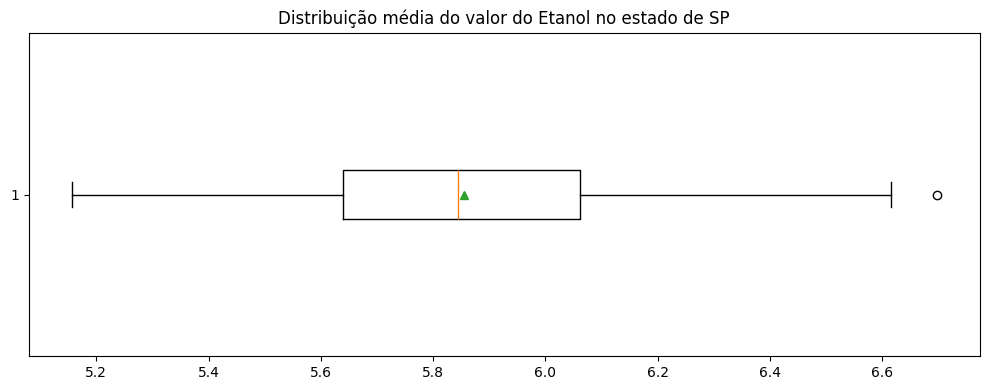

In [137]:
plt.figure(figsize=(10, 4))    
# horizontal: largura maior que altura
plt.boxplot(array_rio, vert=False, showmeans=True)
plt.title('Distribuição média do valor do Etanol no estado de SP')
plt.tight_layout()
plt.show()

In [138]:
df_bairro_sup = df_med_rio.loc[df_posto['Valor de Venda'] > limite_superior]
df_bairro_sup

,Bairro,Valor de Venda
45,LARANJEIRAS,6.237361
76,TAQUARA,5.828841
1,ANDARAI,5.490000


In [139]:
df_bairro_inf = df_med_rio.loc[df_posto['Valor de Venda'] < limite_inferior]
df_bairro_inf

,Bairro,Valor de Venda


In [140]:
df.head()

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


In [141]:
df_br = df.loc[(df['Produto'] == 'GASOLINA')]
df_br

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA
6,NE,AL,ARAPIRACA,IBN PINTO E SILVA & CIA LTDA,01.242.690/0001-58,RODOVIA AL-110,678,KM 70,CANAFISTULA,57302-802,GASOLINA,01/01/2024,5.69,NaN,R$ / litro,BRANCA
10,NE,AL,ARAPIRACA,IBN PINTO E SILVA & CIA LTDA,01.242.690/0002-39,"AVENIDA EMIDIO DE LIMA,",23,NaN,JARDIM ESPERANCA,57307-350,GASOLINA,01/01/2024,5.49,NaN,R$ / litro,IPIRANGA
15,NE,AL,RIO LARGO,CDA EMPREENDIMENTOS LTDA,12.486.809/0004-05,RODOVIA BR 104 AL. KM 86,SN,NaN,MATA DO ROLO,57100-000,GASOLINA,01/01/2024,5.49,NaN,R$ / litro,VIBRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1623419,SE,MG,JANAUBA,M F B NOGUEIRA POSTO DE COMBUSTIVEL LTDA,32275352000227,AVENIDA MILITAO JOSE DOS SANTOS,2596,NaN,PLANALTO,39445-583,GASOLINA,31/12/2025,6.29,NaN,R$ / litro,IPIRANGA
1623420,S,PR,PONTA GROSSA,AUTO POSTO PROGRESSO PONTA GROSSA LTDA,47536308000110,AVENIDA VISCONDE DE TAUNAY,460,NaN,CENTRO,84051-000,GASOLINA,31/12/2025,6.49,NaN,R$ / litro,BRANCA
1623421,SE,MG,ARAGUARI,COMBUSTIVEIS OURO NEGRO IV LTDA,52721170000169,AVENIDA MATO GROSSO,1740,NaN,CENTRO,38440-046,GASOLINA,31/12/2025,5.89,NaN,R$ / litro,IPIRANGA
1623422,S,PR,SAO JOSE DOS PINHAIS,POSTO LINHA VERDE LTDA,38824625000736,RUA ESTELA MARI REZENDE,10789,NaN,BORDA DO CAMPO,83075-452,GASOLINA,31/12/2025,6.79,NaN,R$ / litro,IPIRANGA


In [142]:
df_br_gasolina = df_br.groupby('Estado - Sigla')['Valor de Venda'].mean().reset_index()
df_br_gasolina = df_br_gasolina.sort_values(by= 'Valor de Venda', ascending=False)
df_br_gasolina

,Estado - Sigla,Valor de Venda
0,AC,7.369150
2,AM,6.952820
20,RO,6.760352
21,RR,6.639852
26,TO,6.325683
24,SE,6.320486
19,RN,6.275149
4,BA,6.267518
13,PA,6.239337
17,PR,6.218539


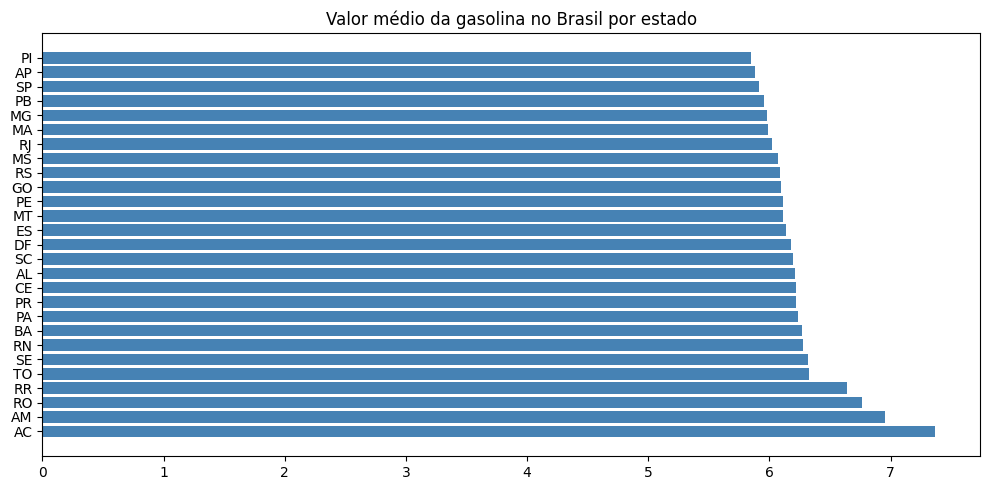

In [143]:
plt.figure(figsize=(10, 5))
plt.barh(df_br_gasolina ['Estado - Sigla'], df_br_gasolina ['Valor de Venda'], color='steelblue')
plt.title('Valor médio da gasolina no Brasil por estado')
plt.tight_layout()    
plt.show()

In [144]:
df_data = df_br.groupby('Data da Coleta')['Valor de Venda'].mean().reset_index()
df_data = df_data.sort_values(by= 'Valor de Venda', ascending=False)
df_data

,Data da Coleta,Valor de Venda
483,27/12/2025,7.324286
174,10/10/2025,6.786316
136,08/08/2025,6.657302
235,14/02/2025,6.568667
87,05/09/2025,6.538649
...,...,...
373,22/01/2024,5.571930
0,01/01/2024,5.560656
448,26/01/2024,5.556327
534,31/01/2024,5.541584


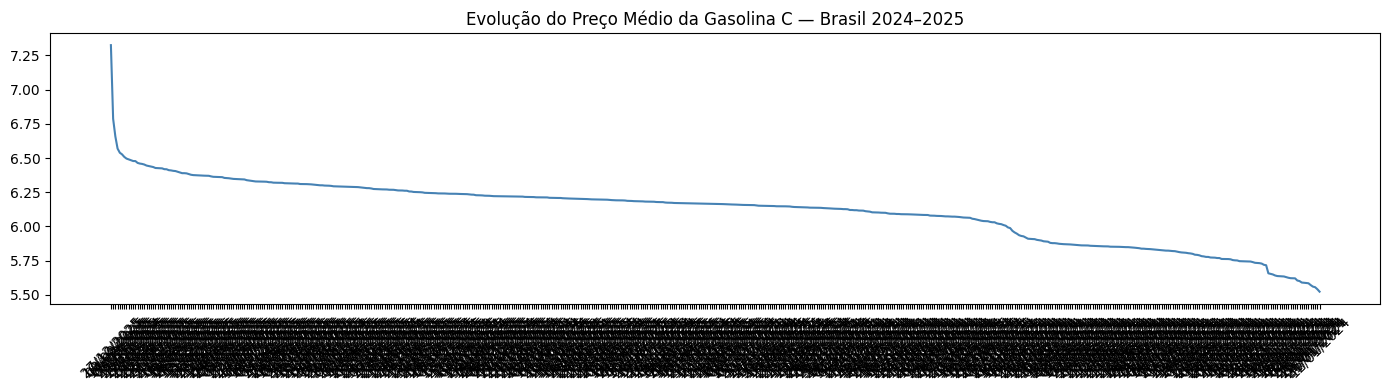

In [145]:
plt.figure(figsize=(14, 4))   
plt.plot(df_data['Data da Coleta'], df_data['Valor de Venda'], color='steelblue')      
plt.title('Evolução do Preço Médio da Gasolina C — Brasil 2024–2025')   
plt.xticks(rotation=45)   
plt.tight_layout()   
plt.show()